# Wealth-in-Utility and Habit Formation in a Consumption-Saving Model with Portfolio Allocation

This notebook is a quick first demonstration of `WealthHabitPortfolioConsumerType` in a life-cycle setting. At this time, it has absolutely no description or analysis. All that is done here is to solve four life-cycle models, with and without habit formation and wealth-in-utility, and compare the life-cycle profiles of average wealth and risky asset share.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.ConsumptionSaving.ConsWealthHabitModel import (
    WealthHabitPortfolioConsumerType,
    WealthHabitPortfolioConsumerType_defaults,
)
from HARK.models import (
    WealthPortfolioConsumerType,
    HabitPortfolioConsumerType,
    RiskyAssetConsumerType,
)
from time import time
from HARK.Calibration.Income.IncomeTools import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
)
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

mystr = lambda x: "{:.4f}".format(x)

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 110
adjust_infl_to = 1992
income_calib = Cagetti_income["College"]
income_calib["PermShkStd"] = 0.1
income_calib["TranShkStd"] = 0.1

# Income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=adjust_infl_to,
    **income_calib,
)

# Survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Start with the default parameters for the wealth-habit-portfolio type
lifecycle_dict = WealthHabitPortfolioConsumerType_defaults.copy()
del lifecycle_dict["constructors"]

# Incorporate the other changes
lifecycle_dict.update(**income_params)
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.01]
lifecycle_dict["RiskyAvg"] = 1.04
lifecycle_dict["RiskyStd"] = 0.18
lifecycle_dict["T_sim"] = 73
lifecycle_dict["CRRA"] = 4.0
lifecycle_dict["DiscFac"] = 0.96
lifecycle_dict["WealthShare"] = 0.2
lifecycle_dict["HabitRte"] = 0.1
lifecycle_dict["HabitWgt"] = 0.3
lifecycle_dict["HabitMax"] = 8.0
lifecycle_dict["HabitCount"] = 51
lifecycle_dict["UnempPrbRet"] = 0.0

# Make a very slightly different dictionary for the habit formation type because of a difference in model timing
habit_LC_dict = lifecycle_dict.copy()
habit_LC_dict["LivPrb"].append(0.0)
habit_LC_dict["Rfree"] = [1.01] + lifecycle_dict["Rfree"]
habit_LC_dict["PermGroFac"] = [1.0] + lifecycle_dict["PermGroFac"]
habit_LC_dict["PermShkStd"] = [0.1] + lifecycle_dict["PermShkStd"]
habit_LC_dict["TranShkStd"] = [0.1] + lifecycle_dict["TranShkStd"]
habit_LC_dict["T_cycle"] += 1

In [3]:
# Make and solve a life-cycle consumer with no habits or wealth-in-utility
BaseType = RiskyAssetConsumerType(RiskyShareFixed=None, **lifecycle_dict)
t0 = time()
BaseType.solve()
t1 = time()
print("Solving the base consumer type took " + mystr(t1 - t0) + " seconds.")

Solving the base consumer type took 0.2521 seconds.


In [4]:
# Make and solve a life-cycle consumer with wealth in the utility function
WealthType = WealthPortfolioConsumerType(**lifecycle_dict)
t0 = time()
WealthType.solve()
t1 = time()
print(
    "Solving the wealth-in-utility consumer type took " + mystr(t1 - t0) + " seconds."
)

Solving the wealth-in-utility consumer type took 0.3051 seconds.


In [5]:
# Make and solve a life-cycle consumer with habit formation
HabitType = HabitPortfolioConsumerType(**habit_LC_dict)
t0 = time()
HabitType.solve()
t1 = time()
print("Solving the habit consumer type took " + mystr(t1 - t0) + " seconds.")

Solving the habit consumer type took 39.7021 seconds.


In [6]:
# Make and solve a life-cycle consumer with habit formation and wealth-in-utility
WealthHabitType = WealthHabitPortfolioConsumerType(**habit_LC_dict)
t0 = time()
WealthHabitType.solve()
t1 = time()
print("Solving the wealth-habit consumer type took " + mystr(t1 - t0) + " seconds.")

Solving the wealth-habit consumer type took 37.2014 seconds.


In [7]:
# Simulate all of the agent types
AgentList = [BaseType, WealthType, HabitType, WealthHabitType]
t0 = time()
for j in range(len(AgentList)):
    agent = AgentList[j]
    agent.initialize_sym(stop_dead=False)
    agent.symulate()
t1 = time()
print("Simulating all of the types took " + mystr(t1 - t0) + " seconds.")

Simulating all of the types took 4.4770 seconds.


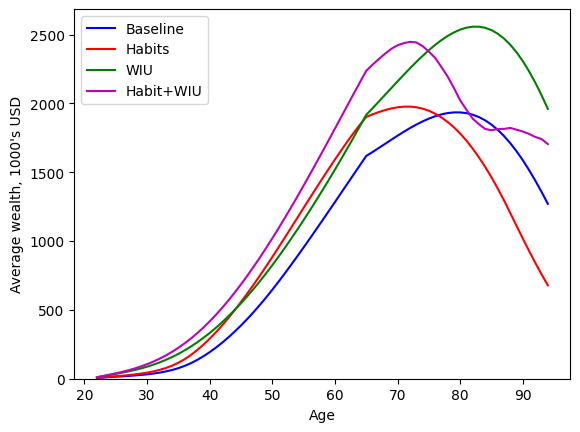

In [8]:
# Extract the history of assets from all consumer types, rescale by permanent income, and average across agents
aLvl_base = BaseType.hystory["aNrm"] * BaseType.hystory["pLvl"]
aLvl_habit = HabitType.hystory["aNrm"] * HabitType.hystory["pLvl"]
aLvl_wealth = WealthType.hystory["aNrm"] * WealthType.hystory["pLvl"]
aLvl_WH = WealthHabitType.hystory["aNrm"] * WealthHabitType.hystory["pLvl"]
A_base = np.mean(aLvl_base, axis=1)
A_habit = np.mean(aLvl_habit, axis=1)
A_wealth = np.mean(aLvl_wealth, axis=1)
A_WH = np.mean(aLvl_WH, axis=1)

# Plot all types' average wealth profile
age_vec = np.arange(22, 95)
plt.plot(age_vec, A_base, "-b")
plt.plot(age_vec, A_habit, "-r")
plt.plot(age_vec, A_wealth, "-g")
plt.plot(age_vec, A_WH, "-m")
plt.legend(["Baseline", "Habits", "WIU", "Habit+WIU"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average wealth, 1000's USD")
plt.ylim(0.0, None)
plt.show()

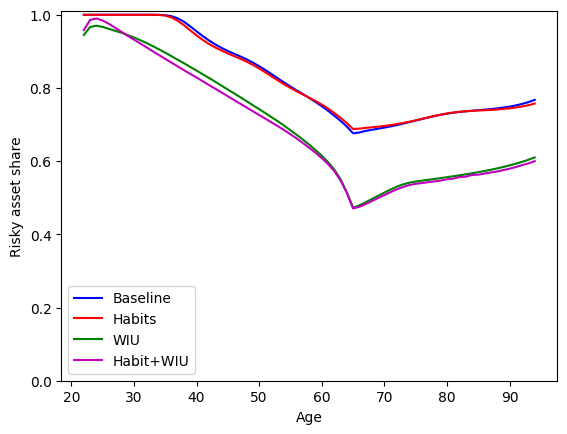

In [9]:
# Extract the history of risky asset share from all consumer types and average across agents
share_base = BaseType.hystory["Share"]
share_habit = HabitType.hystory["Share"]
share_wealth = WealthType.hystory["Share"]
share_WH = WealthHabitType.hystory["Share"]
S_base = np.mean(share_base, axis=1)
S_habit = np.mean(share_habit, axis=1)
S_wealth = np.mean(share_wealth, axis=1)
S_WH = np.mean(share_WH, axis=1)

# Plot all types' risky asset share
age_vec = np.arange(22, 95)
plt.plot(age_vec, S_base, "-b")
plt.plot(age_vec, S_habit, "-r")
plt.plot(age_vec, S_wealth, "-g")
plt.plot(age_vec, S_WH, "-m")
plt.legend(["Baseline", "Habits", "WIU", "Habit+WIU"], loc=3)
plt.xlabel("Age")
plt.ylabel("Risky asset share")
plt.ylim(0.0, 1.01)
plt.show()

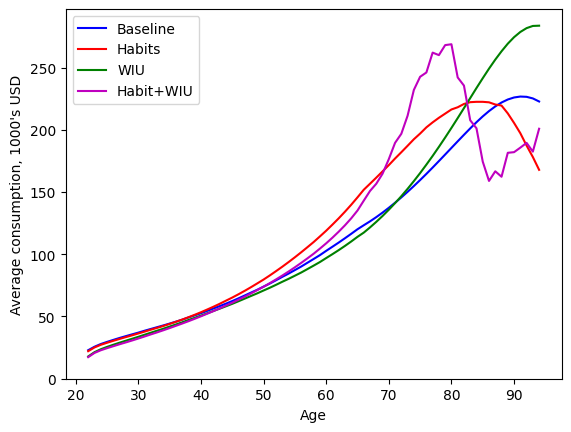

In [10]:
# Extract the history of consumption from all consumer types, rescale by permanent income, and average across agents
cLvl_base = BaseType.hystory["cNrm"] * BaseType.hystory["pLvl"]
cLvl_habit = HabitType.hystory["cNrm"] * HabitType.hystory["pLvl"]
cLvl_wealth = WealthType.hystory["cNrm"] * WealthType.hystory["pLvl"]
cLvl_WH = WealthHabitType.hystory["cNrm"] * WealthHabitType.hystory["pLvl"]
C_base = np.mean(cLvl_base, axis=1)
C_habit = np.mean(cLvl_habit, axis=1)
C_wealth = np.mean(cLvl_wealth, axis=1)
C_WH = np.mean(cLvl_WH, axis=1)

# Plot all types' average consumption profile
age_vec = np.arange(22, 95)
plt.plot(age_vec, C_base, "-b")
plt.plot(age_vec, C_habit, "-r")
plt.plot(age_vec, C_wealth, "-g")
plt.plot(age_vec, C_WH, "-m")
plt.legend(["Baseline", "Habits", "WIU", "Habit+WIU"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average consumption, 1000's USD")
plt.ylim(0.0, None)
plt.show()